In [1]:
# вычисление оценки
# энергии основного состояния
# квантовой системы методом Монте-Карло

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения потенциала
# гармонического осциллятора
def V(x):
    return 0.5 * x**2


In [ ]:
# Ячейка № 3

# задание функции, возвращающей:
# 1) одномерный массив, содержащий
# мгновенные (вычисляемые на каждом шаге)
# метода Монте-Карло значения энергии,
# 2) двумерный массив, содержащий
# мгновенные координаты каждой
# из броуновских частиц (пешеходов),
# сохраненные для тех шагов метода Монте-Карло,
# состояние системы принимается равновесным
def Walk_Shr(N_Walker, S_Range, K, d_S, N_Trial):
    # N_Walker - число использованных броуновских частиц
    # S_Range - размер области случайных блужданий
    # K - доля неиспользованных нестационарных состояний
    # d_S - значение единичного смещения
    #       броуновской частицы
    # N_Trial - число независимых испытаний метода Монте-Карло

    # инициализация начальной конфигурации броуновских частиц
    X_Site = S_Range * np.random.uniform(-0.5, 0.5, N_Walker)

    # вычисление среднего значения энергии
    # начальной конфигурации броуновских частиц
    V_Ref = np.mean(V(X_Site))

    # задание числа броуновсуих частиц в начале испытания
    N_Initial = N_Walker - 1

    # задание начального значения переменной,
    # используемой для хранения значений
    # броуновских частиц в процессе реализации
    # вычислительного алгоритма
    N_Walker_Instant = N_Walker - 1

    # задание значения шага по времени
    dt = d_S**2

    # вычисление числа шагов
    # метода Монет-Карло, соответствующих
    # равновестному состоянию моделируемой системы
    N_Equial = int(K * N_Trial)

    # инициализация массива, используемого
    # хранения мгновенных значений энергии
    # моделируемой системы, находящейся
    # в равновесном состоянии
    E = np.zeros(int((1 - K) * N_Trial))

    # инициализация массива, используемого
    # хранения мгновенных координат
    # броуновских частиц, в моменты времени
    # когда моделируемая системы, находится
    # в равновесном состоянии
    X = np.zeros([N_Walker, int((1 - K) * N_Trial)])

    # задание счетчика числа шагов,
    # соответствующих равновесному
    # соcтоянию системы
    m = 0

    # реализация вычислительного алгоритма
    for i in range(N_Trial):
        # инициализация переменной, используемой
        # для хранения значений суммарной энергии
        # броуновских частиц
        V_Sum = 0

        # реализация метода Монте-Карло
        for j in range(N_Initial, 0, -1):
            # изменяем случайным образом
            # значение координаты
            # j-ой броуновской частицы
            if np.random.uniform(0, 1) < 0.5:
                X_Site[j] = X_Site[j] + d_S
            else:
                X_Site[j] = X_Site[j] - d_S

            # вычисляем значение
            # потенциальной энергии
            # j-ой броуновской частицы
            Potential = V(X_Site[j])

            # вычисляем разность
            # энергий j-й броуновской частиц
            # и среднего значения энергии
            # начальной конфигурации броуновских частиц
            d_V = Potential - V_Ref

            # генерируем случайное число r
            r = np.random.uniform(0, 1)

            # проверяем выполнение условий
            # добавления новой броуновской частицы
            if d_V < 0:
                if r < -d_V * dt:
                    if N_Walker_Instant <= N_Walker - 2:
                        # добавление новой броуновской частицы,
                        # если это число не будет превосходить
                        # начального числа броуновских частиц
                        N_Walker_Instant = N_Walker_Instant + 1
                        X_Site[N_Walker_Instant] = X_Site[j]
                        V_Sum = V_Sum + 2 * Potential
                    else:
                        # в противном случае добавляем энергию
                        # старой броуновской частицы
                        V_Sum = V_Sum + Potential
                else:
                    # условие r < -d_V * dt не выполняется,
                    # добавляем энергию старой броуновской частицы
                    V_Sum = V_Sum + Potential

            else:
                # проверка выполнения условий
                # на удаление броуновской частицы
                if r < d_V * dt:
                    # если условие выполняется,
                    # удаляем броуновскую частицу
                    X_Site[j] = X_Site[N_Walker_Instant]
                    N_Walker_Instant = N_Walker_Instant - 1
                else:
                    # в противном случае добавляем энергию
                    # старой броуновской частицы
                    V_Sum = V_Sum + Potential

        # вычисляем текщее среднее значение потенциала
        V_Ave = V_Sum / N_Walker_Instant

        # сохраняем значения энергии
        # броуновских частиц и их координат,
        # если номер шага больше граничного номера,
        # начиная с которого состояние системы
        # броуновских частиц считается стационарным
        if i > N_Equial:
            E[m] = V_Ave
            X[:, m] = X_Site[:]
            m = m + 1

        # вычисление нового значения опорного потенциала
        V_Ref = V_Ave - (N_Walker_Instant - N_Walker) / (N_Walker * dt)

    return E, X

In [4]:
# Ячейка № 4

# инициализация генератора случайных чисел
np.random.seed()

# задание начального значения
# числа броуновских частиц
N_Walker = 5000

# задание длины
# броуновской частицы
d_S = 0.1

# задание числа независимых испытаний
# метода Монте-Карло
N_Trial = 1000

# задание значения доли неиспользуемых
# неравновесных состояний
K = 0.2

# задание переменной,
# определяющей размер области рассеяния
# броуновских частиц
S_Range = 2

[A, X] = Walk_Shr(N_Walker, S_Range, K, d_S, N_Trial)

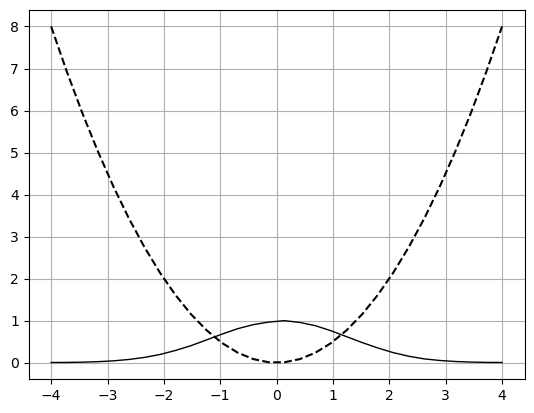


 Энергия основного состояния квантового 
 гармонического осциллятора:  0.5234182427838786


In [ ]:
# Ячейка № 5

# визуализация потенциала и
# нормированной волновой функции
# основного состояния квантового осциллятора

# задание значения числа интервалов гистограммы
Nb = 30

# вычисление координат левого и правого концов,
# интервалов гистограммы
N_bin = np.linspace(-2 * S_Range, 2 * S_Range, Nb)

# инициализация массива, используемого для хранения
# "мгновенных" гистограмм координат
# броуновских частиц
H = np.zeros([Nb, int((1 - K) * N_Trial)])

# ансамбля "мгновенных" гистограмм
# координат броуновских частиц
for i in range(int((1 - K) * N_Trial)):
    Tmp = np.histogram(X[:, i], bins=Nb)
    H[:, i] = Tmp[0]

# визуализация волновой функции
# основного состояния квантового осциллятора

# инициализация массива, используемого
# для хранения значений волновой
# функции основного состояния
# квантового осциллятора
H_mean = np.zeros(Nb)

# вычисление значений волновой
# функции основного состояния
# квантового осциллятора
for i in range(Nb):
    H_mean[i] = np.mean(H[i, :])

# визуализация нормированной
# волновой функции
# основного состояния
# квантового осциллятора
plt.plot(N_bin, H_mean / np.max(H_mean), "-k", lw=1)

# визуализация потенциала
# квантового гармонического осциллятора
plt.plot(N_bin, V(N_bin), "--k")

plt.grid(True)

plt.show()

# вывод значения энергии
print(
    "\n",
    "Энергия основного состояния квантового",
    "\n",
    "гармонического осциллятора: ",
    np.mean(A),
)